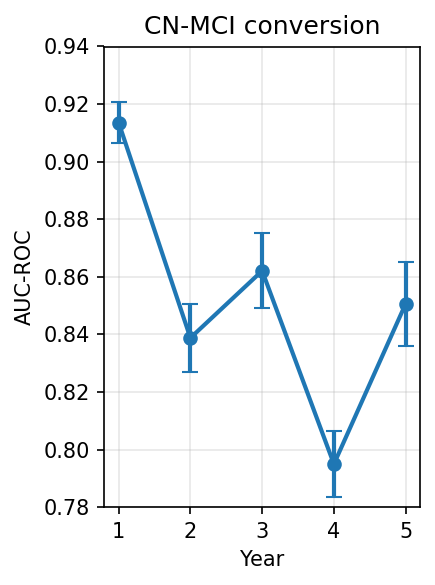

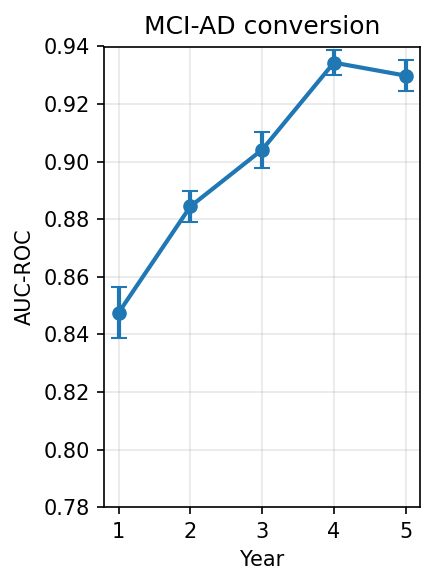

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

auc_df = pd.read_csv("model_outputs.csv", index_col=0)

years = np.arange(1, 6)

def plot_auc_over_years(prefix, title):
    cols = [f"ROCAUC_{prefix}_{year}" for year in years]

    means = auc_df.loc["MEAN", cols].astype(float).to_numpy()
    errors = auc_df.loc["ERR", cols].astype(float).to_numpy()

    fig, ax = plt.subplots(figsize=(3, 4), dpi=150)

    ax.errorbar(
        years,
        means,
        yerr=errors,
        marker="o",
        linewidth=2,
        capsize=4,
    )

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("AUC-ROC")
    ax.set_xticks(years)
    ax.set_ylim(0.78, 0.94)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(f"{title.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    return fig, ax

plot_auc_over_years("CN", "CN-MCI conversion")
plot_auc_over_years("MCI", "MCI-AD conversion")

plt.show()

In [6]:
import numpy as np
import pandas as pd
from math import erfc, sqrt

model = pd.read_csv("model_outputs.csv", index_col=0)
paper = pd.read_csv("paper_outputs.csv", index_col=0)

def two_sided_p_from_z(z):
    return erfc(abs(z) / sqrt(2))

def compare_auc_means(model, paper):
    rows = []

    for col in model.columns:
        model_mean = float(model.loc["MEAN", col])
        model_err = float(model.loc["ERR", col])
        paper_mean = float(paper.loc["MEAN", col])
        paper_err = float(paper.loc["ERR", col])

        diff = model_mean - paper_mean
        se_diff = np.sqrt(model_err**2 + paper_err**2)
        z = diff / se_diff
        p = two_sided_p_from_z(z)

        rows.append({
            "metric": col,
            "model_mean": model_mean,
            "paper_mean": paper_mean,
            "difference": diff,
            "se_difference": se_diff,
            "z": z,
            "p_two_sided": p,
            "significant_0.05": p < 0.05,
        })

    return pd.DataFrame(rows)

auc_comparison = compare_auc_means(model, paper)
auc_comparison


,metric,model_mean,paper_mean,difference,se_difference,z,p_two_sided,significant_0.05
0,ROCAUC_CN_1,0.913587,0.9040,0.009587,0.007888,1.215427,0.224203,False
1,ROCAUC_CN_2,0.838766,0.8628,-0.024034,0.012215,-1.967603,0.049114,True
2,ROCAUC_CN_3,0.862073,0.8578,0.004273,0.013539,0.315615,0.752295,False
3,ROCAUC_CN_4,0.794948,0.8198,-0.024852,0.012078,-2.057516,0.039637,True
4,ROCAUC_CN_5,0.850621,0.8408,0.009821,0.015088,0.650943,0.515083,False
5,ROCAUC_MCI_1,0.847543,0.8542,-0.006657,0.009186,-0.724676,0.468651,False
6,ROCAUC_MCI_2,0.884433,0.8851,-0.000667,0.005689,-0.117271,0.906645,False
7,ROCAUC_MCI_3,0.904137,0.8993,0.004837,0.006463,0.748420,0.454207,False
8,ROCAUC_MCI_4,0.934391,0.9332,0.001191,0.004496,0.264813,0.791154,False
9,ROCAUC_MCI_5,0.929877,0.9284,0.001477,0.005557,0.265776,0.790412,False
